In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Loading Dataset

In [4]:
netflix=pd.read_csv("C:/netflix_titles.csv")
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
netflix.shape

(8807, 12)

In [5]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
netflix.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

## Data Cleaniing 

In [5]:
netflix.country=netflix.country.fillna(netflix.country.mode()[0])
netflix['cast'] = netflix['cast'].fillna("None")
netflix['director'] = netflix['director'].fillna("None")
netflix.dropna(inplace=True)
netflix.drop_duplicates(inplace=True)
netflix.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## VISUALIZATION

## counts by type (movie/TV)

## Countplot

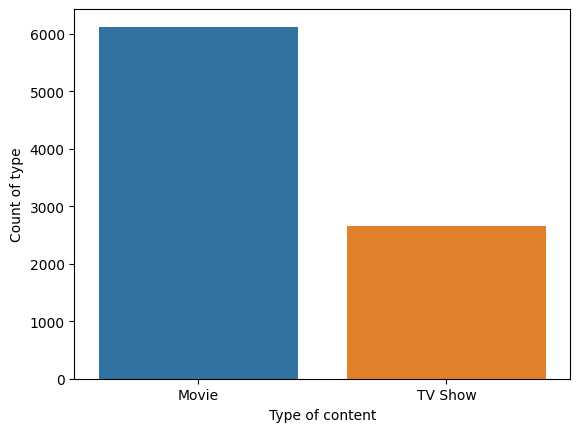

In [21]:
ax=sns.countplot(x="type",data=netflix,palette="tab10",hue="type")
ax.set(xlabel="Type of content",ylabel="Count of type")
plt.savefig("type_distribution.png")

## Piechart

Text(0.5, 1.0, 'Pie chart of type of movies and tv shows')

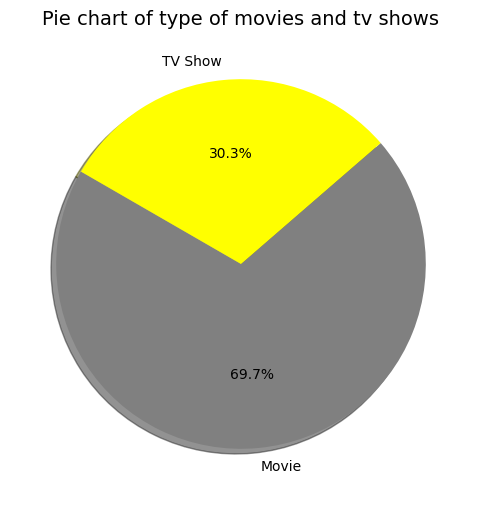

In [16]:
sns.color_palette("hls",8)
type_counts=netflix.type.value_counts()
pie,ax=plt.subplots(figsize=(10,6))
plt.pie(type_counts,labels=type_counts.index,autopct="%1.1f%%",startangle=150,shadow=True,explode=None,colors=["Grey","Yellow"])
plt.title("Pie chart of type of movies and tv shows",fontsize=14)

Movies dominate the Netflix catalog, suggesting a stronger focus on film content compared to episodic TV formats.

## year trends

In [20]:
year_df=pd.DataFrame(netflix["release_year"].value_counts()).reset_index().rename(columns={"count":"total_content_released"})
year_df

,release_year,total_content_released
0,2018,1146
1,2017,1030
2,2019,1030
3,2020,953
4,2016,901
...,...,...
69,1961,1
70,1925,1
71,1959,1
72,1966,1


The number of titles has increased significantly in recent years, indicating rapid expansion of Netflix's content library.

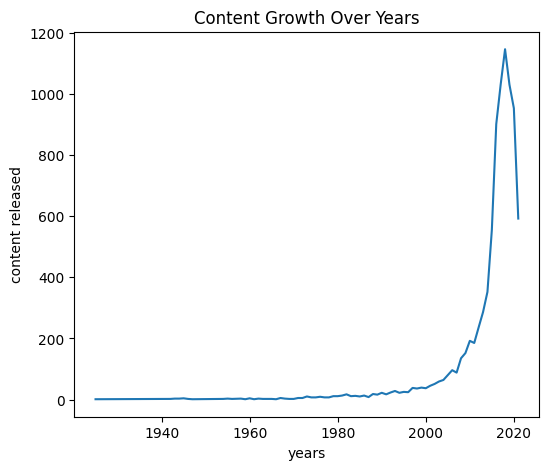

In [22]:
plt.figure(figsize=(6,5))
sns.lineplot(x=year_df["release_year"],y=year_df["total_content_released"])
plt.title("Content Growth Over Years")
plt.xlabel("years")
plt.ylabel("content released")
plt.savefig("year_trend.png")

Text(0, 0.5, 'content released')

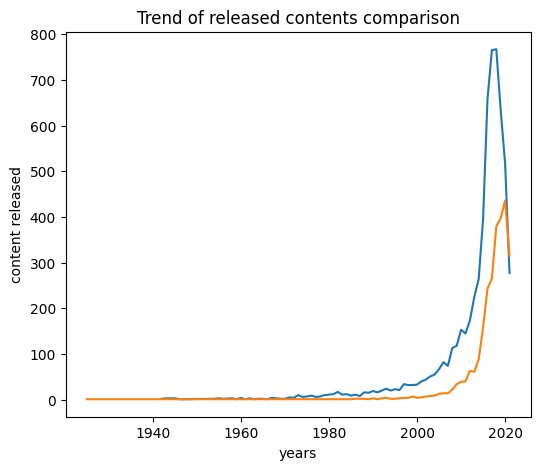

In [23]:
movie_content=netflix[netflix.type=="Movie"]
tv_show_content=netflix[netflix.type=="TV Show"]
movie_year_df=pd.DataFrame(movie_content.release_year.value_counts()).reset_index().rename(columns={"count":"total_content_released"})
tv_show_year_df=pd.DataFrame(tv_show_content.release_year.value_counts()).reset_index().rename(columns={"count":"total_content_released"})
plt.figure(figsize=(6,5))
sns.lineplot(x=movie_year_df["release_year"],y=movie_year_df["total_content_released"])
sns.lineplot(x=tv_show_year_df["release_year"],y=tv_show_year_df["total_content_released"])
plt.title("Trend of released contents comparison")
plt.xlabel("years")
plt.ylabel("content released")

The number of titles has increased significantly in recent years, indicating rapid expansion of Netflix's content library.

##  Top genres

## movie based genre

In [27]:
df_temp=netflix.query("type=='Movie'")
df_temp=df_temp[["title","type","country","listed_in"]]
df_temp=(df_temp.drop("listed_in",axis=1).join(df_temp.listed_in.str.split(",",expand=True).stack().reset_index(drop=True,level=1).rename("Genre")))
df_temp.head()

,title,type,country,Genre
0,Dick Johnson Is Dead,Movie,United States,Documentaries
6,My Little Pony: A New Generation,Movie,United States,Children & Family Movies
7,Sankofa,Movie,"United States, Ghana, Burkina Faso, United Kin...",Dramas
7,Sankofa,Movie,"United States, Ghana, Burkina Faso, United Kin...",Independent Movies
7,Sankofa,Movie,"United States, Ghana, Burkina Faso, United Kin...",International Movies


In [28]:
Genre_df=pd.DataFrame(df_temp.Genre.value_counts().sort_values(ascending=False)).reset_index()
Genre_df.head()

,Genre,count
0,International Movies,2624
1,Dramas,1599
2,Comedies,1210
3,Action & Adventure,859
4,Documentaries,829


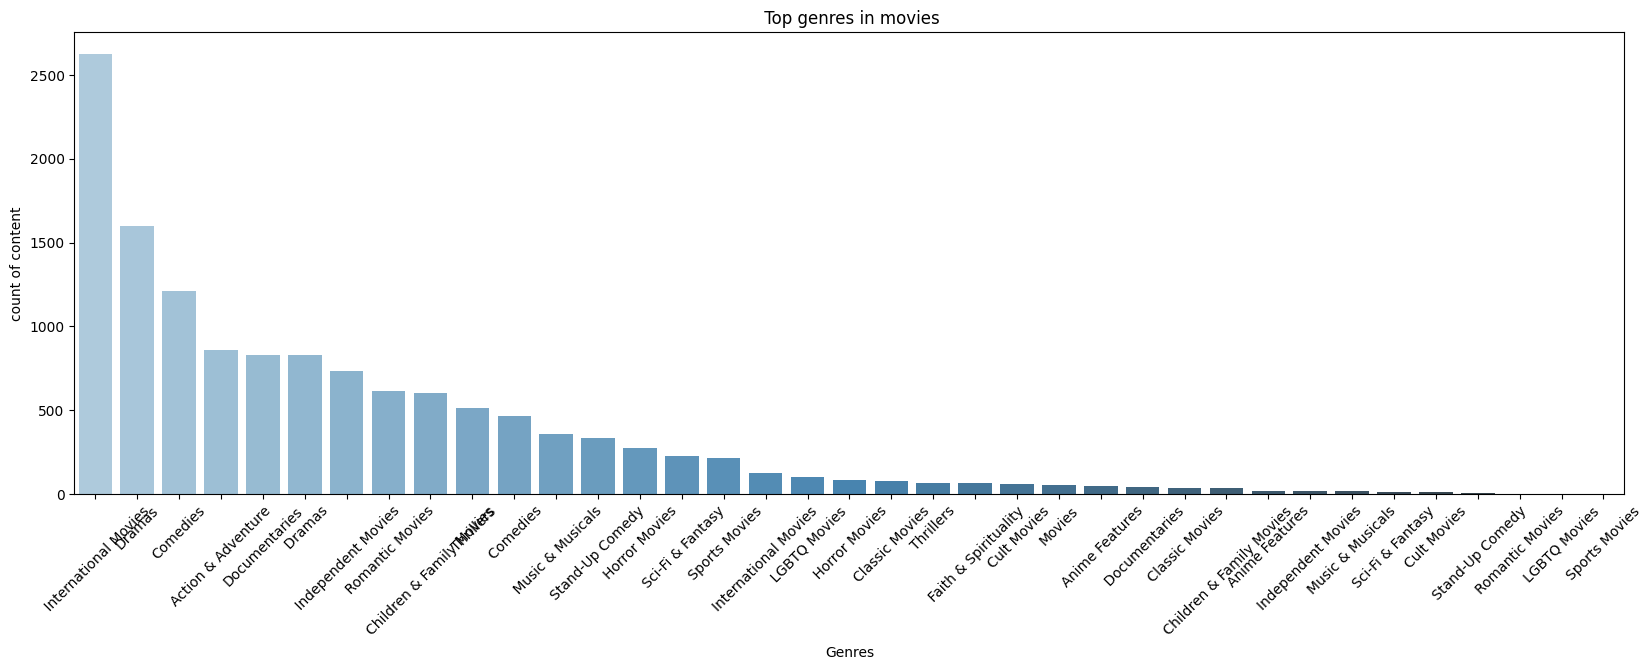

In [29]:
plt.subplots(figsize=(20,6))
sns.barplot(x=Genre_df["Genre"],y=Genre_df["count"],hue=Genre_df["Genre"],legend=False,palette="Blues_d")
plt.title(" Top genres in movies")
plt.xlabel("Genres")
plt.ylabel("count of content")
plt.xticks(rotation=45)
plt.savefig("top_genres_movies.png")
plt.show()

## TV show genre

In [30]:
tv_show_temp=netflix.query("type=='TV Show'")
tv_show_temp=tv_show_temp[["title","type","country","listed_in"]]
tv_show_temp=(tv_show_temp.drop("listed_in",axis=1).join(tv_show_temp.listed_in.str.split(",",expand=True).stack().reset_index(drop=True,level=1).rename("Genre")))
tv_show_temp.head()

,title,type,country,Genre
1,Blood & Water,TV Show,South Africa,International TV Shows
1,Blood & Water,TV Show,South Africa,TV Dramas
1,Blood & Water,TV Show,South Africa,TV Mysteries
2,Ganglands,TV Show,United States,Crime TV Shows
2,Ganglands,TV Show,United States,International TV Shows


In [31]:
Tv_show_Genre_df=pd.DataFrame(tv_show_temp.Genre.value_counts().sort_values(ascending=False)).reset_index()
Tv_show_Genre_df.head()

,Genre,count
0,International TV Shows,773
1,TV Dramas,695
2,International TV Shows,576
3,TV Comedies,454
4,Crime TV Shows,399


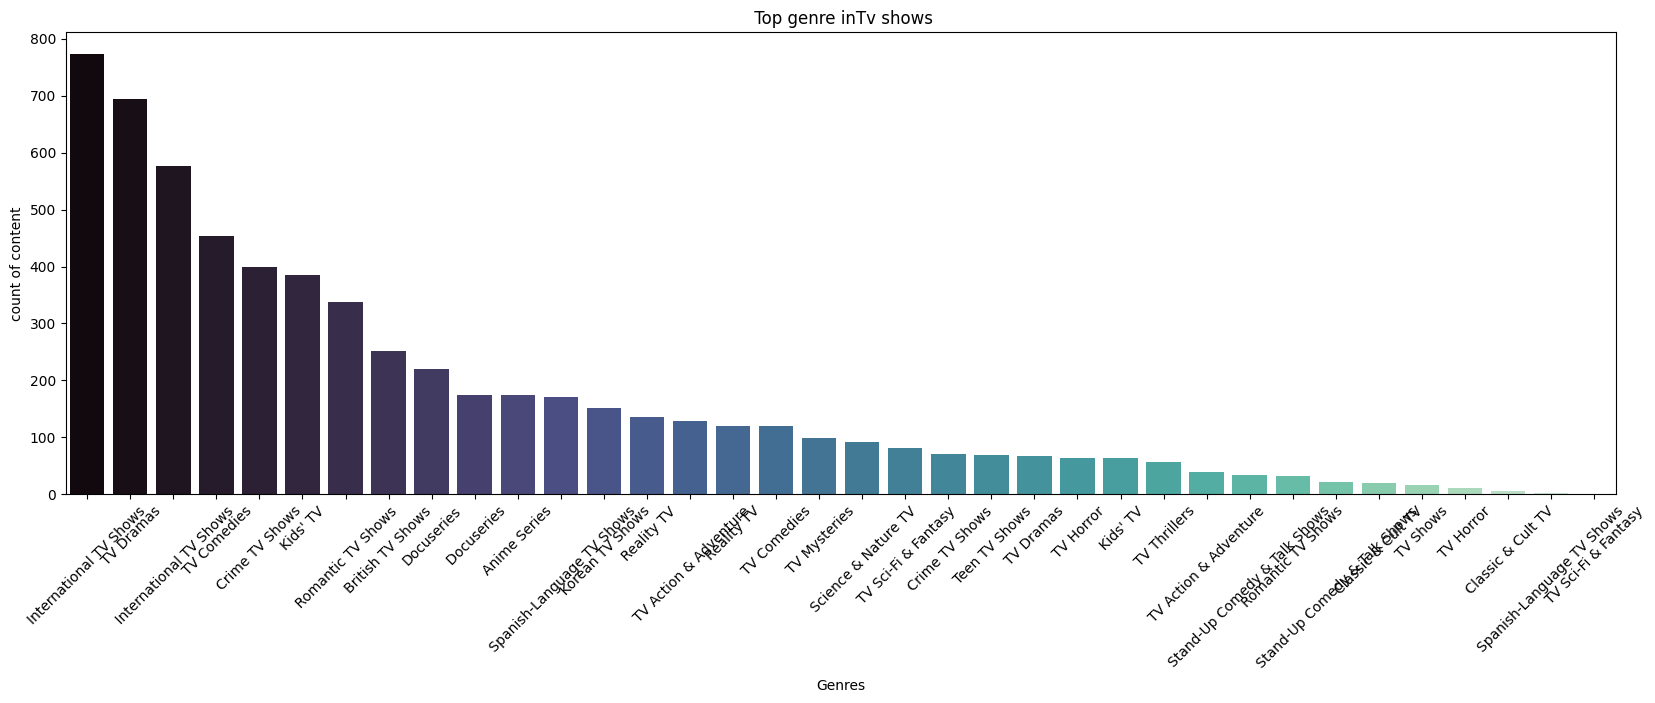

In [32]:
plt.subplots(figsize=(20,6))
sns.barplot(x=Tv_show_Genre_df["Genre"],y=Tv_show_Genre_df["count"],hue=Tv_show_Genre_df["Genre"],legend=False,palette="mako")
plt.title(" Top genre inTv shows")
plt.xlabel("Genres")
plt.ylabel("count of content")
plt.xticks(rotation=45)
plt.savefig("top_genres_tv_shows.png")
plt.show()

Drama and Comedy appear as the most common genres, indicating a strong preference for widely appealing content categories.

## Runtime distribution

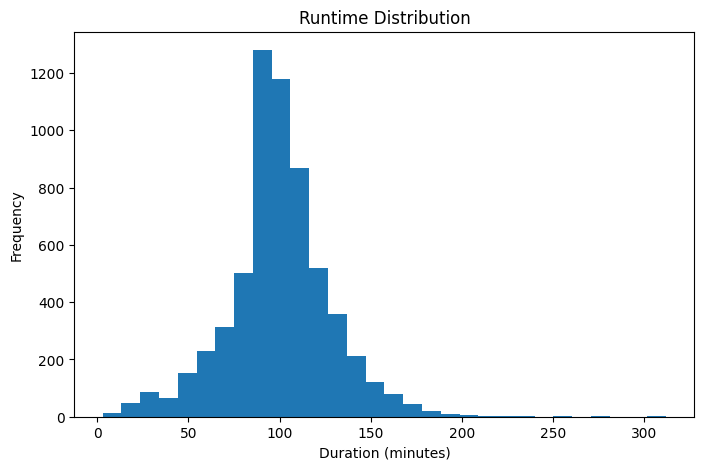

In [11]:
movies = netflix[netflix["type"] == "Movie"].copy()
movies["duration_int"] = movies["duration"].str.extract(r'(\d+)').astype(float)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(movies["duration_int"], bins=30)
plt.title("Runtime Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.savefig("runtime_distribution.png")
plt.show()

The runtime distribution shows that most movies fall within a standard duration range, typically between 80 and 120 minutes. This suggests consistency in movie lengths on the platform.

## Top-10 years

In [36]:
top_years = netflix["release_year"].value_counts().head(10)
print(top_years)

release_year
2018    1146
2017    1030
2019    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: count, dtype: int64


## Top 10 Genres

In [6]:
genres = netflix["listed_in"].str.split(",", expand=True).stack()
genres = genres.str.strip()
top_genres = genres.value_counts().head(10)
print(top_genres)

International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


This analysis highlights Netflix’s rapid content growth and strong focus on movies. Popular genres such as Drama and Comedy dominate the platform, reflecting audience preferences. The study demonstrates how exploratory data analysis can reveal meaningful insights about content strategy and trends.

In [37]:
summary = """
The analysis shows that Movies dominate Netflix content compared to TV Shows. 
There is a significant increase in content over recent years, indicating rapid platform growth. 
Drama and Comedy are among the most common genres. 
The runtime distribution shows that most content falls within a standard duration range. 
Overall, Netflix has expanded rapidly with diverse content across genres.
"""

with open("netflix_summary.txt", "w") as f:
    f.write(summary)